# Session 10 — Deep Ensembles: Implementation 🏥

**Part 2 — Core UQ Algorithms**

> *Training M independent models on the same chest X-rays — and measuring what they disagree about.*

---

### 🎯 What this notebook does

We train **M = 3 DenseNet121 models** on the same chest X-ray dataset, each starting from a different random initialization. Although the models see the same data, they converge to slightly different solutions in parameter space. At test time, we combine their predictions and measure their disagreement as an uncertainty signal — if the ensemble members strongly disagree, the case is likely ambiguous, difficult, or out-of-distribution.

The notebook walks through the full Deep Ensemble pipeline step by step:

* **Data loading and preprocessing** — prepare chest X-rays, apply MONAI transforms, and preserve realistic class imbalance through controlled subsampling
* **Building the Deep Ensemble** — create multiple independently initialized DenseNet121 models trained separately
* **Training ensemble members** — optimize each model individually using cross-entropy loss with early stopping and learning-rate scheduling
* **Measuring ensemble performance** — evaluate the ensemble on the held-out test set using accuracy and AUC-ROC
* **Ensemble inference on the test set** — average predictions across all ensemble members to obtain the final predictive distribution
* **Uncertainty estimation and visualization** — quantify predictive uncertainty using entropy and inter-model disagreement
* **Clustering test cases into certain vs uncertain subgroups** — separate confident and ambiguous cases using uncertainty-based thresholds
* **Statistical comparison between certain and uncertain cases** — test whether ensemble uncertainty meaningfully correlates with predictive reliability
* **Visualization of the most certain and most uncertain chest X-rays** — inspect representative cases with clinical-style interpretation of both the radiograph and the ensemble’s behaviour

---

> **💡 Key difference from Sessions 5 & 6**  
> - **vs VI:** No BayesLinear, no ELBO. M full training runs instead of one modified run.
> - **vs MC Dropout:** No stochastic inference tricks. Each member is fully deterministic — the randomness comes from training, not inference.
> - Uncertainty comes from **disagreement between independently trained models**, not from within a single model.

<div align="center" style="margin-top: 50px;"> <img src="intro.png" width="700" /> </div>

---
## 📦 Part 1 — Installs and imports

In [1]:
!pip install -q monai torch-uncertainty lightning

import os, random, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.mixture import GaussianMixture

# MONAI
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, RepeatChanneld,
    ScaleIntensityd, Resized, RandFlipd, RandRotated, EnsureTyped,
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import DenseNet121

# Torch-Uncertainty
from torch_uncertainty.layers.bayesian import BayesLinear
from torch_uncertainty.losses import ELBOLoss
from torch_uncertainty.metrics.classification import CalibrationError, AURC

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 34.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 43.6 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-15 16:21:32.914457: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778862093.162568      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778862093.229754      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778862093.790069      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778862093.790115      57 computation_placer.cc:1

Device: cuda


---
## 🗂️ Part 2 — Data preparation

Identical to Sessions 5 & 6. Same splits, same ratios.

In [3]:
DATA_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

def is_grayscale(path):
    try:
        return Image.open(path).mode in ['L', 'I;16', 'I']
    except:
        return False

def make_split_list_filtered(split_dir):
    normal_files = sorted(glob.glob(os.path.join(split_dir, 'NORMAL', '*')))
    pneu_files   = sorted(glob.glob(os.path.join(split_dir, 'PNEUMONIA', '*')))
    normal_files = [f for f in normal_files if is_grayscale(f)]
    pneu_files   = [f for f in pneu_files   if is_grayscale(f)]
    return ([{'image': f, 'label': 0} for f in normal_files] +
            [{'image': f, 'label': 1} for f in pneu_files])

def subsample_with_ratio(files, n_total, normal_pneu_ratio, seed=42):

    rng    = np.random.default_rng(seed)
    normal = [d for d in files if int(d['label']) == 0]
    pneu   = [d for d in files if int(d['label']) == 1]
    rng.shuffle(normal)
    rng.shuffle(pneu)

    n_pneu   = int(round(n_total / (1 + normal_pneu_ratio)))
    n_normal = n_total - n_pneu

    n_normal = min(n_normal, len(normal))
    n_pneu   = min(n_pneu,   len(pneu))

    subset = normal[:n_normal] + pneu[:n_pneu]
    rng.shuffle(subset)

    actual = n_normal / n_pneu if n_pneu > 0 else float('inf')
    print(f'  NORMAL={n_normal}, PNEUMONIA={n_pneu}, '
          f'total={len(subset)}')
    return subset

train_files_all = make_split_list_filtered(os.path.join(DATA_DIR, 'train'))
val_files_all   = make_split_list_filtered(os.path.join(DATA_DIR, 'val'))
test_files_all  = make_split_list_filtered(os.path.join(DATA_DIR, 'test'))

print('Train subset (normal:pneu = 2.7:1):')
train_files = subsample_with_ratio(train_files_all, n_total=1000,
                                    normal_pneu_ratio=2.7, seed=SEED)
print('Test subset (normal:pneu = 1.7:1):')
test_files  = subsample_with_ratio(test_files_all,  n_total=100,
                                    normal_pneu_ratio=1.7, seed=SEED)
print(f'Val (full): {len(val_files_all)} samples')

Train subset (normal:pneu = 2.7:1):
  NORMAL=730, PNEUMONIA=270, total=1000
Test subset (normal:pneu = 1.7:1):
  NORMAL=63, PNEUMONIA=37, total=100
Val (full): 16 samples


In [4]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_tfms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    RepeatChanneld(keys=['image'], repeats=3),
    ScaleIntensityd(keys=['image']),
    Resized(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
    RandRotated(keys=['image'], prob=0.3, range_x=0.12),
    EnsureTyped(keys=['image', 'label']),
])
eval_tfms = Compose([
    LoadImaged(keys=['image']),
    EnsureChannelFirstd(keys=['image']),
    RepeatChanneld(keys=['image'], repeats=3),
    ScaleIntensityd(keys=['image']),
    Resized(keys=['image'], spatial_size=(IMG_SIZE, IMG_SIZE)),
    EnsureTyped(keys=['image', 'label']),
])

train_ds = Dataset(data=train_files,   transform=train_tfms)
val_ds   = Dataset(data=val_files_all, transform=eval_tfms)
test_ds  = Dataset(data=test_files,    transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

---
## 🧠 Part 3 — Building the ensemble

Each ensemble member is a standard DenseNet121. The only thing that differs between members is the **random seed** used to initialize the classification head. The backbone starts from the same ImageNet pretrained weights but the different head initialisations lead to genuinely different solutions.

This is the key structural difference from Sessions 5 and 6:

| Session | What varies between forward passes | Source of randomness |
|---|---|---|
| 5 — VI | Sampled weights from $q_\phi(w)$ | Reparameterization trick |
| 6 — MC Dropout | Dropout mask applied to activations | Bernoulli draws |
| 7 — Ensembles | Entire model (different training) | Initialization + training stochasticity |

In [5]:
M          = 3       # number of ensemble members
NUM_EPOCHS = 20

def build_member(seed, num_classes=2, freeze_backbone=True):
    """
    Build one ensemble member — a standard DenseNet121 with a
    fresh classification head seeded differently per member.

    No BayesLinear. No dropout trick. Just a standard model.
    The diversity comes from different random seeds + training stochasticity.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    backbone = DenseNet121(
        spatial_dims=2,
        in_channels=3,
        out_channels=num_classes,
        pretrained=True,
    )

    # Reinitialise the classification head with this member's seed
    # (backbone stays at ImageNet pretrained weights)
    nn.init.kaiming_normal_(backbone.class_layers.out.weight)
    nn.init.zeros_(backbone.class_layers.out.bias)

    if freeze_backbone:
        for name, param in backbone.named_parameters():
            if 'class_layers' not in name:
                param.requires_grad = False

    return backbone.to(device)


# Build M members with different seeds
member_seeds = [42, 123, 777]
ensemble     = [build_member(seed) for seed in member_seeds]

print(f'Ensemble size: M = {M} members')
trainable = sum(p.numel() for p in ensemble[0].parameters() if p.requires_grad)
print(f'Trainable params per member: {trainable:,}')
print(f'Total trainable params (M×): {trainable * M:,}')
print()
print('Compare with Session 5 (VI): 2 × head params (mu + sigma)')
print('Compare with Session 6 (MC Dropout): 1 × head params (standard)')
print('Deep Ensembles: M × head params — cost scales with M')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 174MB/s]


Ensemble size: M = 3 members
Trainable params per member: 2,050
Total trainable params (M×): 6,150

Compare with Session 5 (VI): 2 × head params (mu + sigma)
Compare with Session 6 (MC Dropout): 1 × head params (standard)
Deep Ensembles: M × head params — cost scales with M


---
## ⚙️ Part 4 — Training all M members

Each member trains independently with its own optimizer and scheduler. We track each member's training history separately — showing that they do in fact converge to slightly different solutions despite starting from similar initialisations.

In [7]:
# Deep Ensemble Training

M          = 3
NUM_EPOCHS = 100

EARLY_STOP_PATIENCE = 10
PLATEAU_PATIENCE    = 3
PLATEAU_FACTOR      = 0.5
MIN_LR              = 1e-6

loss_fn = nn.CrossEntropyLoss()

all_history      = []
best_model_paths = []

# Train each ensemble member independently

for m_idx, (model, seed) in enumerate(zip(ensemble, member_seeds)):

    print(f'\n{"="*60}')
    print(f'Training member {m_idx+1}/{M}  (seed={seed})')
    print(f'{"="*60}')

    # ---------------------------------------------------------------------
    # Reproducibility
    # ---------------------------------------------------------------------
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    # ---------------------------------------------------------------------
    # Optimizer
    # ---------------------------------------------------------------------
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3,
    )

    # ---------------------------------------------------------------------
    # Scheduler
    # ---------------------------------------------------------------------
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=PLATEAU_FACTOR,
        patience=PLATEAU_PATIENCE,
        threshold=1e-3,
        threshold_mode='rel',
        min_lr=MIN_LR,
    )

    # ---------------------------------------------------------------------
    # Best-model tracking
    # ---------------------------------------------------------------------
    best_val_loss = np.inf

    patience_counter = 0

    best_path = (
        f'/kaggle/working/best_member_{m_idx+1}.pth'
    )

    best_model_paths.append(best_path)

    # ---------------------------------------------------------------------
    # History
    # ---------------------------------------------------------------------
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_auc': [],
        'lr': [],
    }

    for epoch in range(1, NUM_EPOCHS + 1):

        # -----------------------------------------------------------------
        # TRAIN
        # -----------------------------------------------------------------
        model.train()

        epoch_loss = 0.0

        for batch in tqdm(
            train_loader,
            desc=f'  Epoch {epoch:02d}/{NUM_EPOCHS}',
            leave=False
        ):

            images = batch['image'].to(
                device,
                dtype=torch.float32
            )

            labels = batch['label'].to(
                device,
                dtype=torch.long
            )

            optimizer.zero_grad()

            logits = model(images)

            loss = loss_fn(logits, labels)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)

        # -----------------------------------------------------------------
        # VALIDATION
        # -----------------------------------------------------------------
        model.eval()

        val_loss = 0.0

        val_probs  = []
        val_preds  = []
        val_labels = []

        with torch.no_grad():

            for batch in val_loader:

                images = batch['image'].to(
                    device,
                    dtype=torch.float32
                )

                labels_tensor = batch['label'].to(
                    device,
                    dtype=torch.long
                )

                logits = model(images)

                loss = loss_fn(logits, labels_tensor)

                val_loss += loss.item()

                probs = torch.softmax(
                    logits,
                    dim=-1
                ).cpu().numpy()

                labels = labels_tensor.cpu().numpy()

                val_probs.extend(probs[:, 1].tolist())

                val_preds.extend(
                    probs.argmax(axis=1).tolist()
                )

                val_labels.extend(labels.tolist())

        avg_val_loss = val_loss / len(val_loader)

        val_acc = accuracy_score(
            val_labels,
            val_preds
        )

        val_auc = roc_auc_score(
            val_labels,
            val_probs
        )

        # -----------------------------------------------------------------
        # Scheduler update
        # -----------------------------------------------------------------
        scheduler.step(avg_val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        # -----------------------------------------------------------------
        # Save metrics
        # -----------------------------------------------------------------
        history['train_loss'].append(avg_train_loss)

        history['val_loss'].append(avg_val_loss)

        history['val_acc'].append(val_acc)

        history['val_auc'].append(val_auc)

        history['lr'].append(current_lr)

        # -----------------------------------------------------------------
        # Save best model
        # -----------------------------------------------------------------
        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss

            patience_counter = 0

            torch.save(
                model.state_dict(),
                best_path
            )

            print(
                f'✅ Saved best model '
                f'(val_loss={best_val_loss:.4f})'
            )

        else:

            patience_counter += 1

        # -----------------------------------------------------------------
        # Logging
        # -----------------------------------------------------------------
        print(
            f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
            f'Train Loss: {avg_train_loss:.4f} | '
            f'Val Loss: {avg_val_loss:.4f} | '
            f'Val Acc: {val_acc:.3f} | '
            f'Val AUC: {val_auc:.3f} | '
            f'LR: {current_lr:.6f}'
        )

        # -----------------------------------------------------------------
        # Early stopping
        # -----------------------------------------------------------------
        if patience_counter >= EARLY_STOP_PATIENCE:

            print()

            print(
                f'🛑 Early stopping triggered '
                f'for member {m_idx+1}'
            )

            break

    # ---------------------------------------------------------------------
    # Save history
    # ---------------------------------------------------------------------
    all_history.append(history)

print('\n🎉 All ensemble members trained!')


Training member 1/3  (seed=42)


✅ Saved best model (val_loss=0.4384)
Epoch 01/100 | Train Loss: 0.4255 | Val Loss: 0.4384 | Val Acc: 0.938 | Val AUC: 1.000 | LR: 0.001000


✅ Saved best model (val_loss=0.3410)
Epoch 02/100 | Train Loss: 0.2737 | Val Loss: 0.3410 | Val Acc: 0.938 | Val AUC: 1.000 | LR: 0.001000


Epoch 03/100 | Train Loss: 0.2117 | Val Loss: 0.3747 | Val Acc: 0.812 | Val AUC: 0.953 | LR: 0.001000


✅ Saved best model (val_loss=0.3040)
Epoch 04/100 | Train Loss: 0.1931 | Val Loss: 0.3040 | Val Acc: 0.938 | Val AUC: 0.969 | LR: 0.001000


...

Epoch 12/100 | Train Loss: 0.1394 | Val Loss: 0.3099 | Val Acc: 0.750 | Val AUC: 0.953 | LR: 0.000500


Epoch 13/100 | Train Loss: 0.1390 | Val Loss: 0.3372 | Val Acc: 0.750 | Val AUC: 0.953 | LR: 0.000500


Epoch 14/100 | Train Loss: 0.1433 | Val Loss: 0.3312 | Val Acc: 0.750 | Val AUC: 0.953 | LR: 0.000250


Epoch 15/100 | Train Loss: 0.1299 | Val Loss: 0.3749 | Val Acc: 0.750 | Val AUC: 0.953 | LR: 0.000250


Epoch 16/100 | Train Loss: 0.1327 | Val Loss: 0.3037 | Val Acc: 0.750 | Val AUC: 0.953 | LR: 0.000250

🛑 Early stopping triggered for member 3

🎉 All ensemble members trained!


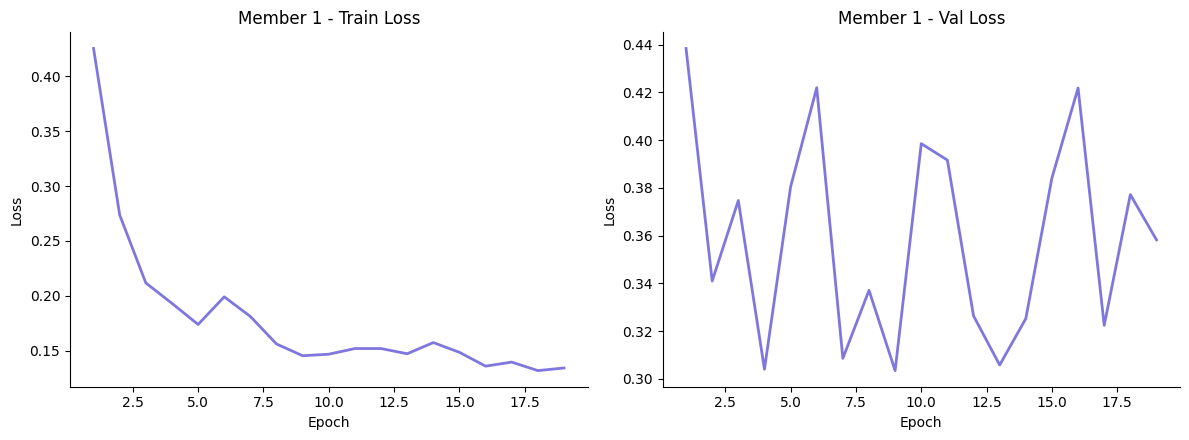

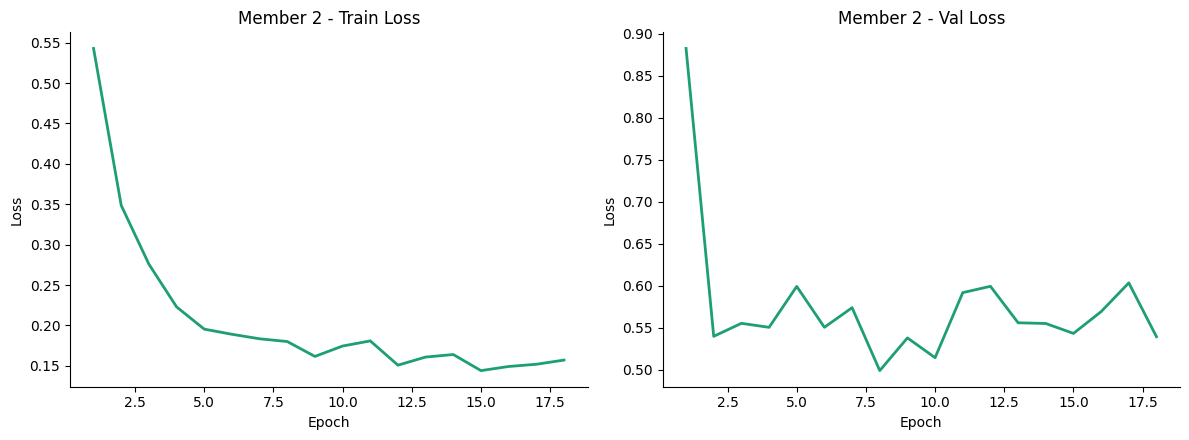

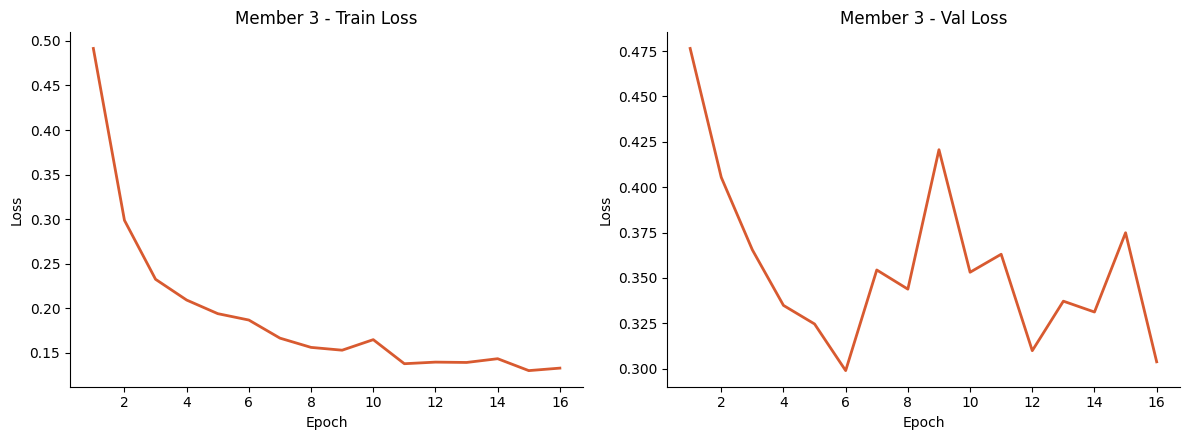

In [11]:
# ── Train & validation loss curves (separate figure per member) ─────────────

colors_m = ['#7F77DD', '#1D9E75', '#D85A30']

for m_idx, (h, color) in enumerate(zip(all_history, colors_m)):

    epochs = range(1, len(h['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # ── Train loss (left) ─────────────────────────────
    axes[0].plot(
        epochs,
        h['train_loss'],
        color=color,
        linewidth=2
    )
    axes[0].set_title(f'Member {m_idx+1} - Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].spines[['top', 'right']].set_visible(False)

    # ── Validation loss (right) ───────────────────────
    axes[1].plot(
        epochs,
        h['val_loss'],
        color=color,
        linewidth=2
    )
    axes[1].set_title(f'Member {m_idx+1} - Val Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

---
## 🔮 Part 5 — Ensemble inference

Unlike VI and MC Dropout, ensemble inference is fully deterministic per member. Each member gives one prediction per input. Uncertainty comes entirely from the spread across M deterministic predictions — not from stochasticity within any single forward pass.

In [15]:
# Load BEST weights for all ensemble members

# I renamed the best models and added them to inputs

model_paths = [
    '/kaggle/input/models/benyamingheiji/de-best-model1/pytorch/default/1/DE_best_model1.pth',
    '/kaggle/input/models/benyamingheiji/de-best-model2/pytorch/default/1/DE_best_model2.pth',
    '/kaggle/input/models/benyamingheiji/de-best-model3/pytorch/default/1/DE_best_model3.pth'
]

for m_idx, (model, path) in enumerate(zip(ensemble, model_paths)):

    model.load_state_dict(
        torch.load(path, map_location=device)
    )

    model.eval()

    print(
        f'✅ Loaded best weights for '
        f'Member {m_idx+1} from {path}'
    )

print('\n🎯 All best ensemble members restored!')

✅ Loaded best weights for Member 1 from /kaggle/input/models/benyamingheiji/de-best-model1/pytorch/default/1/DE_best_model1.pth
✅ Loaded best weights for Member 2 from /kaggle/input/models/benyamingheiji/de-best-model2/pytorch/default/1/DE_best_model2.pth
✅ Loaded best weights for Member 3 from /kaggle/input/models/benyamingheiji/de-best-model3/pytorch/default/1/DE_best_model3.pth

🎯 All best ensemble members restored!


In [17]:
def ensemble_inference(ensemble, loader, device=device):
    """
    Ensemble inference: one deterministic forward pass per member per image.

    Key difference from VI and MC Dropout:
    - No stochastic sampling during inference
    - Each member is fully deterministic (model.eval(), no dropout)
    - Uncertainty = disagreement between M independent predictions

    Returns results DataFrame and raw image tensors.
    """
    for m in ensemble:
        m.eval()

    all_mean_preds, all_entropy, all_variance = [], [], []
    all_epistemic, all_aleatoric              = [], []
    all_labels, all_paths, all_images         = [], [], []
    # Per-member predictions for diversity analysis
    all_member_preds = [[] for _ in ensemble]

    with torch.no_grad():
        for batch in tqdm(loader, desc='Ensemble inference'):
            images = batch['image'].to(device, dtype=torch.float32)
            labels = batch['label'].cpu().numpy()
            paths  = (batch.get('image_meta_dict', {}).get('filename_or_obj')
                      or [''] * len(labels))

            # One deterministic pass per member
            member_probs = []
            for m_idx, m in enumerate(ensemble):
                probs = torch.softmax(m(images), dim=-1).cpu().numpy()  # [B, 2]
                member_probs.append(probs)
                all_member_preds[m_idx].extend(probs[:, 1].tolist())

            member_probs = np.stack(member_probs, axis=0)  # [M, B, 2]
            mean_probs   = member_probs.mean(axis=0)       # [B, 2]

            # Total uncertainty: predictive entropy of the mean
            total_H = -np.sum(
                mean_probs * np.log(mean_probs + 1e-8), axis=-1
            )

            # Aleatoric: average entropy per member
            per_H       = -np.sum(
                member_probs * np.log(member_probs + 1e-8), axis=-1
            )  # [M, B]
            aleatoric_H = per_H.mean(axis=0)

            # Epistemic: mutual information
            epistemic_MI = total_H - aleatoric_H

            # Variance of P(pneumonia) across members
            variance = member_probs[:, :, 1].var(axis=0)

            all_mean_preds.extend(mean_probs[:, 1].tolist())
            all_entropy.extend(total_H.tolist())
            all_epistemic.extend(epistemic_MI.tolist())
            all_aleatoric.extend(aleatoric_H.tolist())
            all_variance.extend(variance.tolist())
            all_labels.extend(labels.tolist())
            all_paths.extend(list(paths))
            all_images.extend(images.cpu().unbind(0))

    preds   = (np.array(all_mean_preds) >= 0.5).astype(int)
    correct = (preds == np.array(all_labels)).astype(int)

    results = pd.DataFrame({
        'image_path'        : all_paths,
        'true_label'        : all_labels,
        'mean_pred'         : all_mean_preds,
        'pred_label'        : preds.tolist(),
        'predictive_entropy': all_entropy,
        'epistemic_mi'      : all_epistemic,
        'aleatoric_h'       : all_aleatoric,
        'variance'          : all_variance,
        'correct'           : correct.tolist(),
    })
    return results, all_images, all_member_preds


results, test_images, member_preds = ensemble_inference(
    ensemble, test_loader, device=device
)

print(f'Test samples  : {len(results)}')
print(f'Accuracy      : {results["correct"].mean():.3f}')
print(f'AUC-ROC       : {roc_auc_score(results["true_label"], results["mean_pred"]):.3f}')

print()
print('Per-member performance:')

for m_idx, preds_m in enumerate(member_preds):

    preds_m   = np.array(preds_m)

    preds_bin = (preds_m >= 0.5).astype(int)

    acc_m = (
        preds_bin == results['true_label'].values
    ).mean()

    auc_m = roc_auc_score(
        results['true_label'],
        preds_m
    )

    print(
        f'  Member {m_idx+1} '
        f'| Accuracy: {acc_m:.3f} '
        f'| AUC: {auc_m:.3f}'
    )

print()
print(
    f'Ensemble '
    f'| Accuracy: {results["correct"].mean():.3f} '
    f'| AUC: {roc_auc_score(results["true_label"], results["mean_pred"]):.3f}'
)

Ensemble inference: 100%|██████████| 4/4 [00:07<00:00,  1.79s/it]

Test samples  : 100
Accuracy      : 0.900
AUC-ROC       : 0.948

Per-member performance:
  Member 1 | Accuracy: 0.890 | AUC: 0.952
  Member 2 | Accuracy: 0.900 | AUC: 0.946
  Member 3 | Accuracy: 0.870 | AUC: 0.932

Ensemble | Accuracy: 0.900 | AUC: 0.948


## 🎲 Part 6 — Uncertainty decomposition across the test set

We now analyse how the Bayesian model decomposes predictive uncertainty on unseen chest X-rays into total, epistemic, and aleatoric components. The following plots show the distribution of uncertainty across the test set, the contribution of each uncertainty type per case, and the relationship between prediction confidence and uncertainty

In [18]:
print('Uncertainty decomposition (mean across test set):')
print(f'  Total entropy  : {results["predictive_entropy"].mean():.4f}')
print(f'  Epistemic (MI) : {results["epistemic_mi"].mean():.4f}')
print(f'  Aleatoric (H)  : {results["aleatoric_h"].mean():.4f}')

Uncertainty decomposition (mean across test set):
  Total entropy  : 0.3097
  Epistemic (MI) : 0.0148
  Aleatoric (H)  : 0.2950


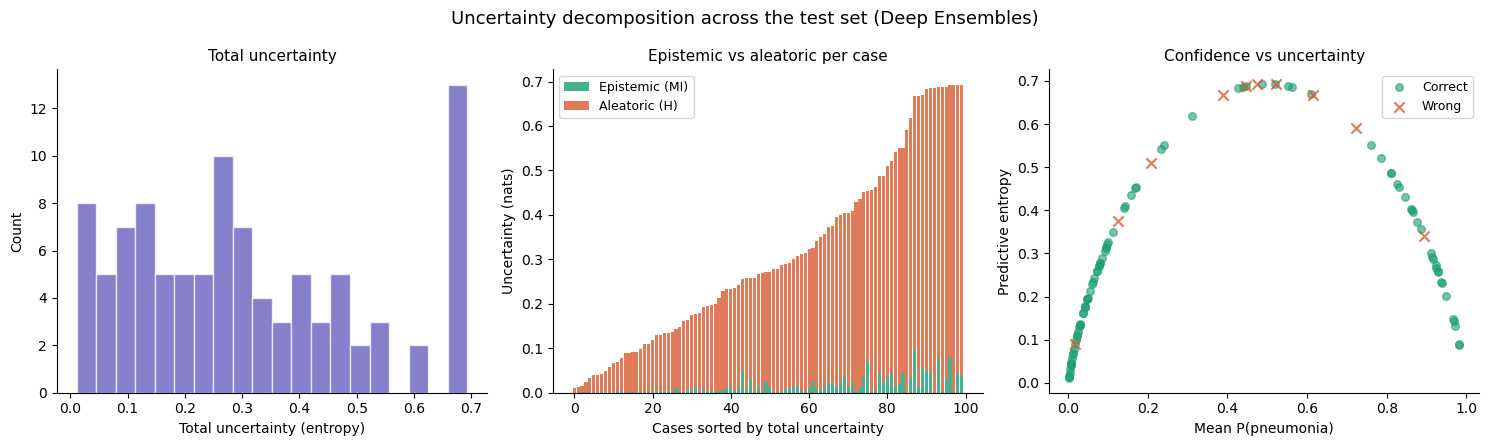

In [4]:
# ── Uncertainty decomposition visualisation ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Uncertainty decomposition across the test set (Deep Ensembles)', fontsize=13)

# Total entropy
axes[0].hist(results['predictive_entropy'], bins=20,
             color='#534AB7', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Total uncertainty (entropy)', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Total uncertainty', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)

# Epistemic vs aleatoric per case
idx_sorted = results['predictive_entropy'].argsort().values
axes[1].bar(range(len(results)),
            results['epistemic_mi'].values[idx_sorted],
            color='#1D9E75', alpha=0.8, label='Epistemic (MI)')
axes[1].bar(range(len(results)),
            results['aleatoric_h'].values[idx_sorted],
            bottom=results['epistemic_mi'].values[idx_sorted],
            color='#D85A30', alpha=0.8, label='Aleatoric (H)')
axes[1].set_xlabel('Cases sorted by total uncertainty', fontsize=10)
axes[1].set_ylabel('Uncertainty (nats)', fontsize=10)
axes[1].set_title('Epistemic vs aleatoric per case', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

# Correct vs wrong
correct_mask = results['correct'].astype(bool)
axes[2].scatter(results.loc[correct_mask, 'mean_pred'],
                results.loc[correct_mask, 'predictive_entropy'],
                c='#1D9E75', alpha=0.6, s=30, label='Correct')
axes[2].scatter(results.loc[~correct_mask, 'mean_pred'],
                results.loc[~correct_mask, 'predictive_entropy'],
                c='#D85A30', alpha=0.8, s=55, marker='x', label='Wrong')
axes[2].set_xlabel('Mean P(pneumonia)', fontsize=10)
axes[2].set_ylabel('Predictive entropy', fontsize=10)
axes[2].set_title('Confidence vs uncertainty', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The figure illustrates the uncertainty decomposition obtained from the **Deep Ensembles** framework on the test set. The left panel shows the distribution of total predictive uncertainty, measured using entropy, across all test samples. The middle panel decomposes the uncertainty for each test case into **epistemic uncertainty**, reflecting uncertainty in the model parameters, and **aleatoric uncertainty**, reflecting inherent ambiguity in the data. Test cases are sorted by increasing total uncertainty, revealing that aleatoric uncertainty is the dominant contributor for most samples, while epistemic uncertainty remains relatively small but increases for the most uncertain cases. The right panel relates the model’s predicted probability for the positive class to predictive entropy, showing that uncertainty is highest for intermediate-confidence predictions and lowest for highly confident predictions near 0 or 1. Misclassified cases tend to occur in regions of elevated uncertainty, indicating that the model appropriately assigns greater uncertainty to more challenging predictions.

---
## 📊 Part 7 — Clustering certain vs uncertain cases

We split the test set into **certain** and **uncertain** groups using the gaussian mixture model, then:

1. Compare accuracy and AUC between groups
2. Run a **Mann-Whitney U test** (non-parametric, no normality assumption) to check whether the uncertainty scores of correct and wrong predictions are statistically distinguishable

If VI produces meaningful uncertainty, the uncertain group should have lower accuracy — the model should be less reliable precisely when it says it's unsure.

In [24]:
# Run stochastic inference on validation set
# We use validation entropy distribution to LEARN the uncertainty threshold.
# Then we apply that threshold to the TEST set.

val_results, _, _ = ensemble_inference(
    ensemble,
    val_loader,
    device=device
)

# Fit GMM on VALIDATION entropy

X_val = val_results['predictive_entropy'].values.reshape(-1, 1)

gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm.fit(X_val)

# Find threshold between the two Gaussians

means = gmm.means_.flatten()
means = np.sort(means)

# midpoint between Gaussian means
threshold = means.mean()

print('GMM learned from VALIDATION set')
print(f'Cluster means         : {means}')
print(f'Entropy threshold     : {threshold:.4f}')

Ensemble inference: 100%|██████████| 1/1 [00:01<00:00,  1.31s/it]

GMM learned from VALIDATION set
Cluster means         : [0.24458214 0.5393396 ]
Entropy threshold     : 0.3920



Certain group   : 67 cases
Uncertain group : 33 cases

📊 Certain vs Uncertain Summary


,Group,N Cases,Accuracy,AUC-ROC,Mean Entropy,Mean Variance
0,Certain,67,0.9552,0.9583,0.1870,0.0009
1,Uncertain,33,0.7879,0.8704,0.5590,0.0121



📊 Mann-Whitney U test
H0: entropy(correct) == entropy(wrong)
U statistic : 177.00
p-value     : 0.0009

📊 Z-test for accuracy difference
H0: accuracy(certain) == accuracy(uncertain)
Z statistic : 2.623
p-value     : 0.0087


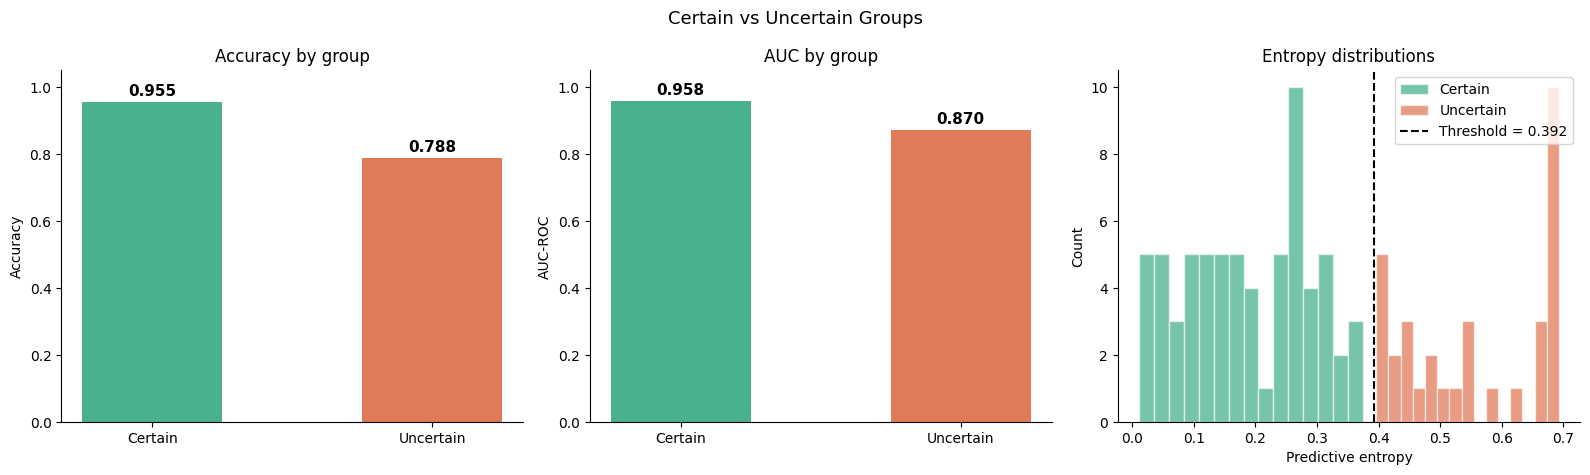

In [25]:
# Apply threshold to TEST set

results['uncertainty_group'] = np.where(
    results['predictive_entropy'] > threshold,
    'Uncertain',
    'Certain'
)

certain   = results[results['uncertainty_group'] == 'Certain']
uncertain = results[results['uncertainty_group'] == 'Uncertain']

print()
print(f'Certain group   : {len(certain)} cases')
print(f'Uncertain group : {len(uncertain)} cases')


# Metrics function

def group_metrics(df, name):

    acc = df['correct'].mean()

    auc = (
        roc_auc_score(df['true_label'], df['mean_pred'])
        if df['true_label'].nunique() > 1
        else float('nan')
    )

    mean_ent = df['predictive_entropy'].mean()
    mean_var = df['variance'].mean()

    return {
        'Group'         : name,
        'N Cases'       : len(df),
        'Accuracy'      : acc,
        'AUC-ROC'       : auc,
        'Mean Entropy'  : mean_ent,
        'Mean Variance' : mean_var,
    }


# Compute metrics

certain_metrics   = group_metrics(certain, 'Certain')
uncertain_metrics = group_metrics(uncertain, 'Uncertain')

summary_df = pd.DataFrame([
    certain_metrics,
    uncertain_metrics
])

summary_display = summary_df.copy()

for col in ['Accuracy', 'AUC-ROC', 'Mean Entropy', 'Mean Variance']:
    summary_display[col] = summary_display[col].map(lambda x: f'{x:.4f}')

print('\n📊 Certain vs Uncertain Summary')
display(summary_display)


# Extract values

acc_cert   = certain_metrics['Accuracy']
acc_uncert = uncertain_metrics['Accuracy']

auc_cert   = certain_metrics['AUC-ROC']
auc_uncert = uncertain_metrics['AUC-ROC']


# Mann-Whitney U test (entropy difference between correct vs wrong)

entropy_correct = results.loc[
    results['correct'] == 1,
    'predictive_entropy'
].values

entropy_wrong = results.loc[
    results['correct'] == 0,
    'predictive_entropy'
].values

if len(entropy_wrong) > 0 and len(entropy_correct) > 0:

    stat, p_value = stats.mannwhitneyu(
        entropy_correct,
        entropy_wrong,
        alternative='less'
    )

    print()
    print('📊 Mann-Whitney U test')
    print('H0: entropy(correct) == entropy(wrong)')

    print(f'U statistic : {stat:.2f}')
    print(f'p-value     : {p_value:.4f}')


# Accuracy comparison (z-test)

stat2, p2 = proportions_ztest(
    [
        int(acc_cert * len(certain)),
        int(acc_uncert * len(uncertain))
    ],
    [
        len(certain),
        len(uncertain)
    ]
)

print()
print('📊 Z-test for accuracy difference')
print('H0: accuracy(certain) == accuracy(uncertain)')

print(f'Z statistic : {stat2:.3f}')
print(f'p-value     : {p2:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

fig.suptitle(
    'Certain vs Uncertain Groups',
    fontsize=13
)

groups = ['Certain', 'Uncertain']
colors = ['#1D9E75', '#D85A30']


# Accuracy comparison

axes[0].bar(groups, [acc_cert, acc_uncert], color=colors, alpha=0.8, width=0.5)

axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by group')

for i, v in enumerate([acc_cert, acc_uncert]):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

axes[0].spines[['top', 'right']].set_visible(False)


# AUC comparison (descriptive only)

axes[1].bar(groups, [auc_cert, auc_uncert], color=colors, alpha=0.8, width=0.5)

axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC by group')

for i, v in enumerate([auc_cert, auc_uncert]):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

axes[1].spines[['top', 'right']].set_visible(False)


# Entropy distributions

axes[2].hist(
    certain['predictive_entropy'],
    bins=15,
    alpha=0.6,
    color='#1D9E75',
    edgecolor='white',
    label='Certain'
)

axes[2].hist(
    uncertain['predictive_entropy'],
    bins=15,
    alpha=0.6,
    color='#D85A30',
    edgecolor='white',
    label='Uncertain'
)

axes[2].axvline(
    threshold,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Threshold = {threshold:.3f}'
)

axes[2].set_xlabel('Predictive entropy')
axes[2].set_ylabel('Count')
axes[2].set_title('Entropy distributions')
axes[2].legend()

axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

The figure compares model performance between test samples classified as **certain** and **uncertain** based on a predictive entropy threshold of **0.392** derived from the Deep Ensemble uncertainty estimates. The left panel shows that the model achieves substantially higher accuracy on the certain group (**95.5%**) than on the uncertain group (**78.8%**). The middle panel demonstrates a similar trend for discrimination performance, with AUC-ROC decreasing from **0.958** in the certain group to **0.870** in the uncertain group. The right panel visualizes the entropy distributions for both groups, showing a clear separation between low-entropy (certain) and high-entropy (uncertain) samples around the chosen threshold. These results indicate that predictive entropy effectively identifies more challenging cases, with uncertain samples exhibiting markedly lower predictive performance and reliability.


---
## 🏥 Part 8 — Medical visualization

In [26]:
# Visualisation helper

LABEL_NAMES = {0: 'Normal', 1: 'Pneumonia'}

def tensor_to_display(x):

    # take first channel
    img = x[0].numpy()

    # rotate 90° clockwise
    img = np.rot90(img, k=-1)

    # mirror flip (left-right flip)
    img = np.fliplr(img)

    return np.clip(img, 0, 1)


def plot_xray_group(indices, results_df, images_list,
                    group_title, n_show=2):

    indices = list(indices)[:n_show]

    if not indices:
        print(f'No cases to show for: {group_title}')
        return

    fig, axes = plt.subplots(
        1,
        len(indices),
        figsize=(5 * len(indices), 5.5)
    )

    if len(indices) == 1:
        axes = [axes]

    fig.suptitle(
        group_title,
        fontsize=13,
        fontweight='bold',
        y=1.02
    )

    for ax, idx in zip(axes, indices):

        row = results_df.loc[idx]

        # now rotated + mirrored
        img = tensor_to_display(images_list[idx])

        ax.imshow(img, cmap='gray')
        ax.axis('off')

        true_name = LABEL_NAMES[int(row['true_label'])]
        pred_name = LABEL_NAMES[int(row['pred_label'])]

        verdict = '✓ Correct' if row['correct'] else '✗ Wrong'

        color = '#1D9E75' if row['correct'] else '#D85A30'

        title = (
            f'{verdict}\n'
            f'True: {true_name}\n'
            f'Pred: {pred_name} ({row["mean_pred"]:.2f})\n'
            f'Entropy: {row["predictive_entropy"]:.4f}\n'
            f'Variance: {row["variance"]:.5f}'
        )

        ax.set_title(
            title,
            fontsize=9,
            color=color,
            pad=5
        )

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_57/2731258473.py:76: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


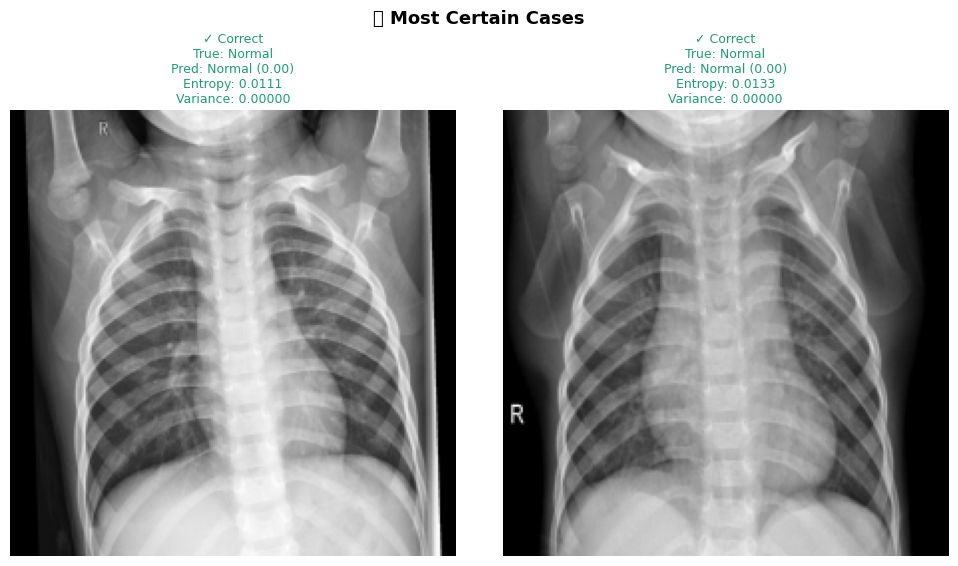

In [27]:
# MOST CERTAIN CASES

most_certain_idx = (
    certain
    .nsmallest(2, 'predictive_entropy')
    .index.tolist()
)

plot_xray_group(
    most_certain_idx,
    results,
    test_images,
    '🟢 Most Certain Cases'
)

/tmp/ipykernel_57/2731258473.py:76: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


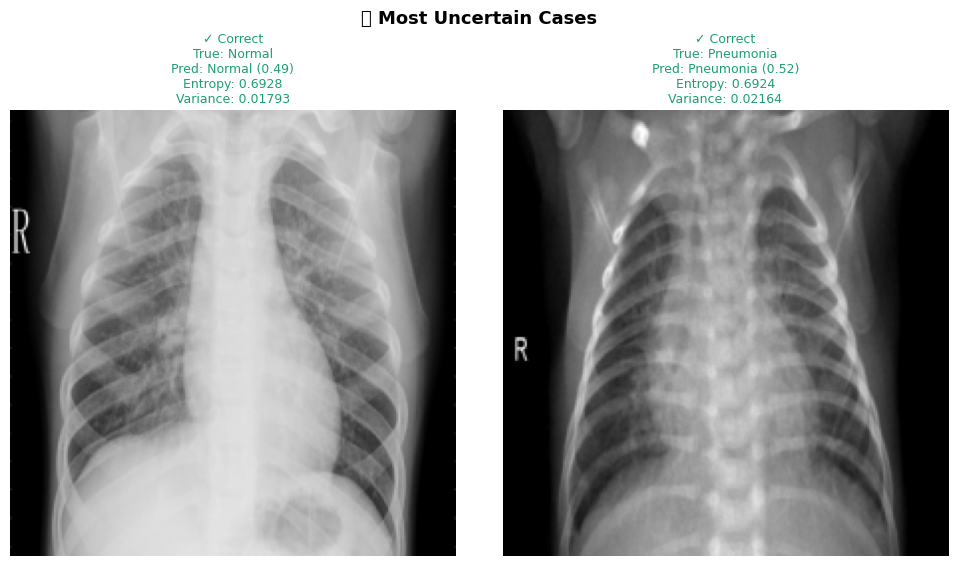

In [28]:
# MOST UNCERTAIN CASES

most_uncertain_idx = (
    uncertain
    .nlargest(2, 'predictive_entropy')
    .index.tolist()
)

plot_xray_group(
    most_uncertain_idx,
    results,
    test_images,
    '🔴 Most Uncertain Cases'
)


---
## 💾 Part 9 — Save results

In [29]:
results['method'] = 'Deep_Ensembles'

save_path = '/kaggle/working/results_de.csv'
results.to_csv(save_path, index=False)

print(f'Results saved to: {save_path}')

Results saved to: /kaggle/working/results_de.csv


---
## ✅ Session summary

| Step | What we did |
|---|---|
| 🗂️ Data | Subsampled with class ratios (normal:pneu = 2.7:1 train, 1.7:1 test) |
| 🧠 Model | M=3 standard DenseNet121 instances, different random seeds |
| ⚙️ Training | Standard CE × M — one independent run per member |
| 🔮 Inference | One deterministic pass per member — uncertainty from disagreement |
| 🧩 Decomposition | Total = Epistemic (MI) + Aleatoric (expected H) — per image |
| 📊 Statistics | Mann-Whitney U test on entropy and accuracy of correct vs wrong predictions |
| 🏥 Visualization | Most Certain and Most Uncertain cases |


> **➡️ Next: Session 11 — Evidential Deep Learning**  
> What if a neural network could represent uncertainty directly in its output, without an ensemble or repeated stochastic forward passes?